In [1]:
import math as m
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

from scipy.stats import linregress

import statistics as st




import functools as ft

In [2]:
path_name = '../data/co2_mm_mlo.csv'
mauna = pd.read_csv(path_name, comment='#')

In [3]:
print(mauna)


     year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0    1958      3     1958.2027   315.71          314.44     -1 -9.99 -0.99
1    1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2    1958      5     1958.3699   317.51          314.69     -1 -9.99 -0.99
3    1958      6     1958.4548   317.27          315.15     -1 -9.99 -0.99
4    1958      7     1958.5370   315.87          315.20     -1 -9.99 -0.99
..    ...    ...           ...      ...             ...    ...   ...   ...
813  2025     12     2025.9583   427.49          428.22     24  0.32  0.12
814  2026      1     2026.0417   428.62          428.34     25  0.69  0.27
815  2026      2     2026.1250   429.35          428.40     17  0.74  0.35
816  2026      3     2026.2083   430.15          428.72     26  0.86  0.32
817  2026      4     2026.2917   431.12          428.70     23  1.13  0.45

[818 rows x 8 columns]


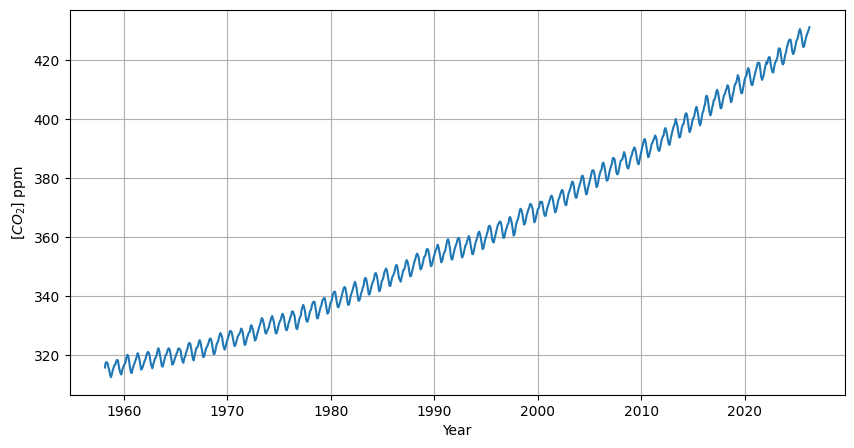

In [4]:
mauna["date"] = pd.to_datetime(
    dict(year=mauna["year"], month=mauna["month"], day=1)
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(mauna["date"], mauna["average"])
plt.xlabel("Year")
plt.ylabel(r"[$CO_2$] ppm")
plt.grid(True)
plt.savefig("../img/keeling.pdf")
plt.show()

In [5]:
# Extract December values
mauna_dec = mauna.loc[mauna["month"] == 12, ["year", "average"]].copy()

# December of year N should be used as reference for year N+1
mauna_dec["year"] += 1
mauna_dec = mauna_dec.rename(columns={"average": "dec_average"})

# Merge with original dataframe
mauna_year = mauna.merge(mauna_dec, on="year", how="left")

# Increase relative to previous December
mauna_year["increase"] = mauna_year["average"] - mauna_year["dec_average"]

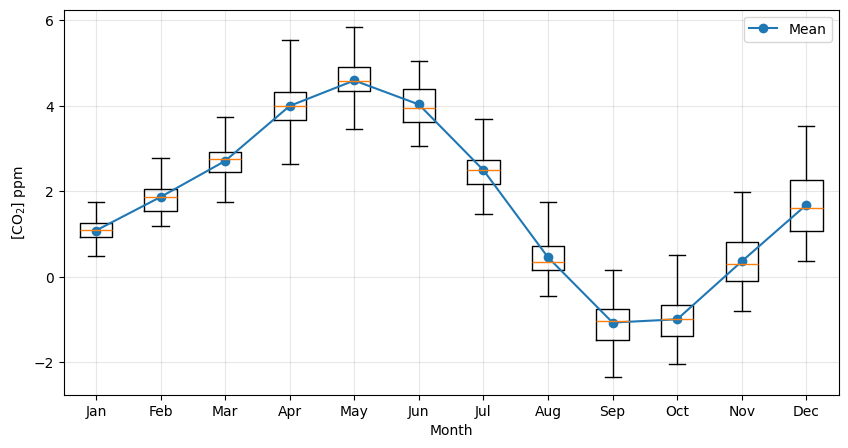

In [6]:
months = range(1, 13)

box_data = [
    mauna_year.loc[mauna_year["month"] == m, "increase"].dropna()
    for m in months
]

means = [
    mauna_year.loc[mauna_year["month"] == m, "increase"].mean()
    for m in months
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(box_data, positions=months, whis=(0, 100))
ax.plot(months, means, "o-", label="Mean")

ax.set_xticks(months)
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_xlabel("Month")

ax.set_ylabel(r"[CO$_2$] ppm")
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig("../img/yearly-variations.pdf")

plt.show()

In [7]:
path_name = '../data/Global_Carbon_Budget_2025_v0.6.csv'

fossil = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=",",
    dtype={"Year": "int64"}
)

fossil["Other"] = fossil[["Cement", "Flaring", "Other"]].sum(axis=1)

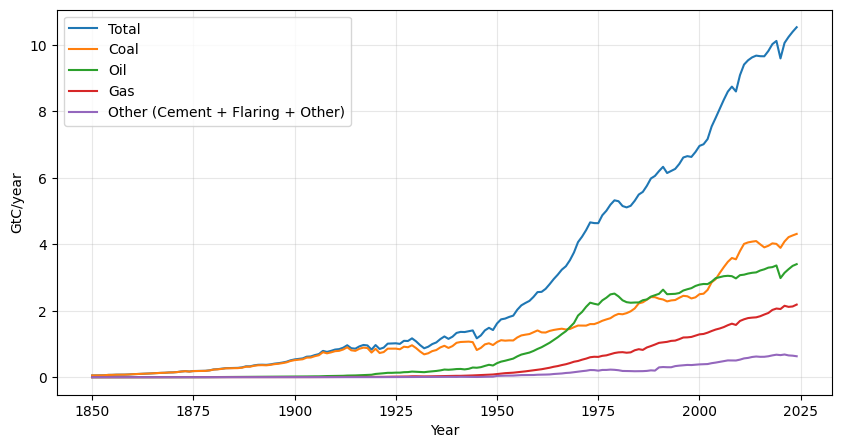

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(fossil["Year"], fossil["Total"], label="Total")
ax.plot(fossil["Year"], fossil["Coal"], label="Coal")
ax.plot(fossil["Year"], fossil["Oil"], label="Oil")
ax.plot(fossil["Year"], fossil["Gas"], label="Gas")
ax.plot(fossil["Year"], fossil["Other"], label="Other (Cement + Flaring + Other)")

ax.set_xlabel("Year")
ax.set_ylabel("GtC/year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../img/gcb.pdf")
plt.show()

In [9]:
sorted = fossil.sort_values("Year")

cols = ["Total", "Coal", "Oil", "Gas", "Other"]

cum = sorted.copy()
cum[cols] = cum[cols].cumsum()

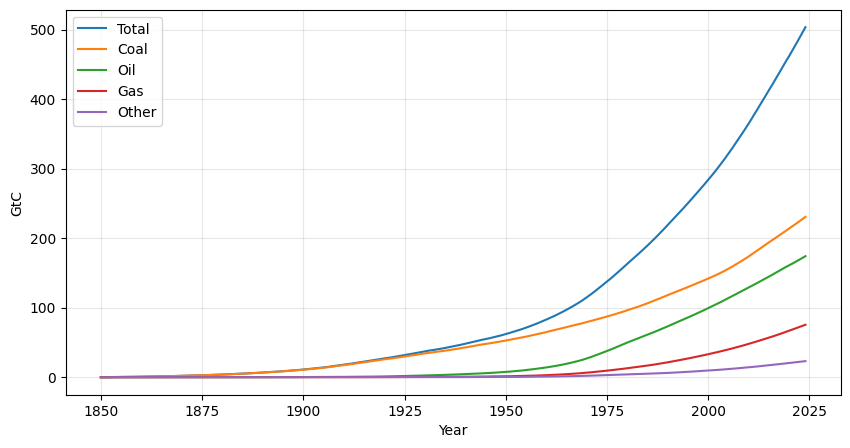

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for c in cols:
    ax.plot(cum["Year"], cum[c], label=c)

ax.set_xlabel("Year")
ax.set_ylabel("GtC")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../img/gcb-cum.pdf")
plt.show()

In [11]:
cum[cum["Year"] == 1958]

,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Capita
108,1958,77.94244,62.21497,12.435137,2.507049,0.035397,0.025959,0.785283,0.000789


In [12]:
fossil[fossil["Year"] == 2024]

,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Capita
174,2024,10.534546,4.313661,3.403547,2.186088,0.40197,0.113457,0.63125,0.001291


In [13]:
atm = mauna.loc[mauna["month"] == 12, ["year", "average"]].copy()

atm["incr"] = atm["average"].diff()
atm = atm.loc[(atm["year"] >= 1959) & (atm["year"] <= 2024),
              ["year", "incr"]].reset_index(drop="True")

fos = fossil.loc[
    (fossil["Year"] >= 1959) &
    (fossil["Year"] <= 2024),
    ["Year", "Total"]
].copy()

fos = fos.rename(columns={
    "Year": "year",
    "Total": "emi"
})

# Convert GtC to ppm
fos["emi"] = fos["emi"] / 2.13



In [14]:
atm

,year,incr
0,1959,0.91
1,1960,0.61
2,1961,0.82
3,1962,0.69
4,1963,0.65
...,...,...
61,2020,2.26
62,2021,2.44
63,2022,2.32
64,2023,2.87


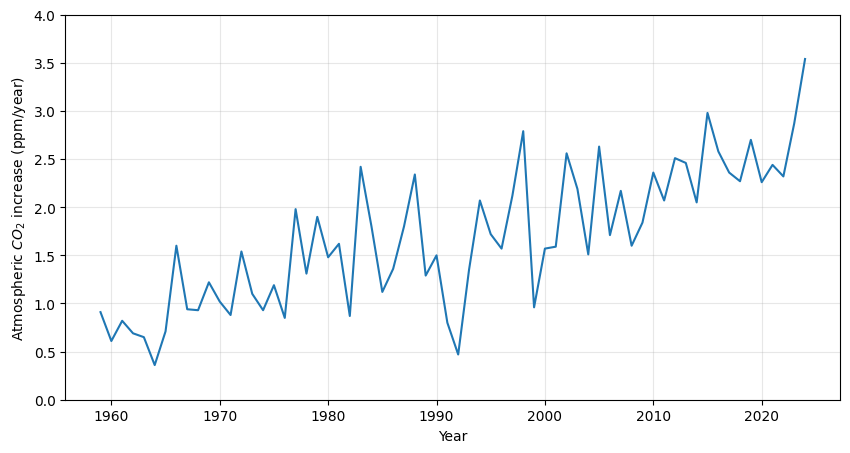

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(
    atm['year'],
    atm['incr']
)

ax.set_ylim(0.0,4.0)
ax.set_xlabel("Year")
ax.set_ylabel(r"Atmospheric $CO_2$ increase (ppm/year)")

ax.grid(True, alpha=0.3)

plt.savefig("../img/increase.pdf")

plt.show()

Slope      = 0.505
Intercept  = 0.150
r          = 0.794
R²         = 0.631
p-value    = 1.763e-15


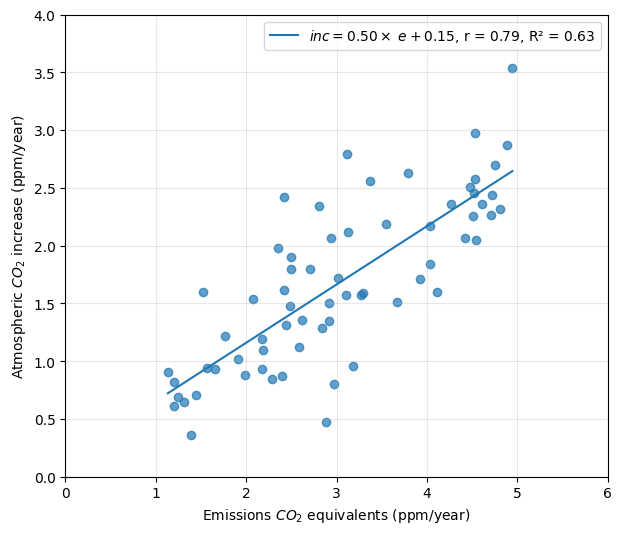

In [21]:
x = fos["emi"]
y = atm["incr"]

res = linregress(x, y)

print(f"Slope      = {res.slope:.3f}")
print(f"Intercept  = {res.intercept:.3f}")
print(f"r          = {res.rvalue:.3f}")
print(f"R²         = {res.rvalue**2:.3f}")
print(f"p-value    = {res.pvalue:.3e}")


fig, ax = plt.subplots(figsize=(7, 6))

# Scatter
ax.scatter(x, y, alpha=0.7)

# Regression line
xfit = np.linspace(x.min(), x.max(), 100)
yfit = res.intercept + res.slope * xfit

ax.plot(
    xfit,
    yfit,
    label=f"$inc = {res.slope:.2f} \\times\\; e + 0.15$, r = {res.rvalue:.2f}, R² = {res.rvalue**2:.2f}"
)

ax.set_xlim(0.0, 6.0)
ax.set_ylim(0.0,4.0)
ax.set_xlabel("Emissions $CO_2$ equivalents (ppm/year)")
ax.set_ylabel(r"Atmospheric $CO_2$ increase (ppm/year)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig("../carbon/img/emissions-ppm.pdf")

plt.show()

In [22]:
path_name = '../data/uahncdc_lt_6.1.csv'

uah = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=".",
    dtype={"Year": "int64", "Mo": "int64"}
)

uah["Date"] = pd.to_datetime(dict(year=uah["Year"], month=uah["Mo"], day=1))

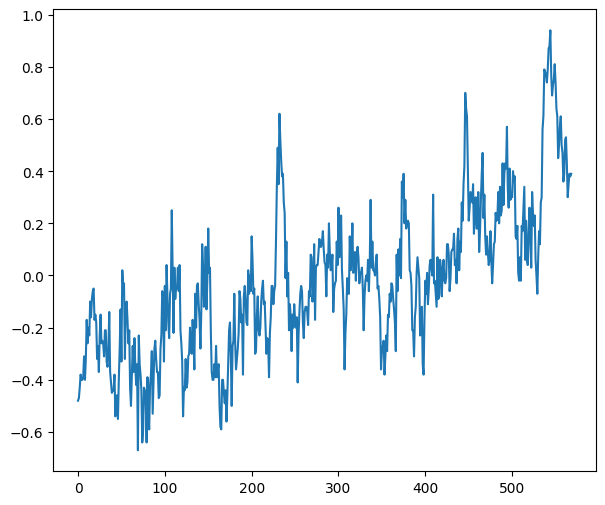

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))



plt.plot(uah["Globe"])

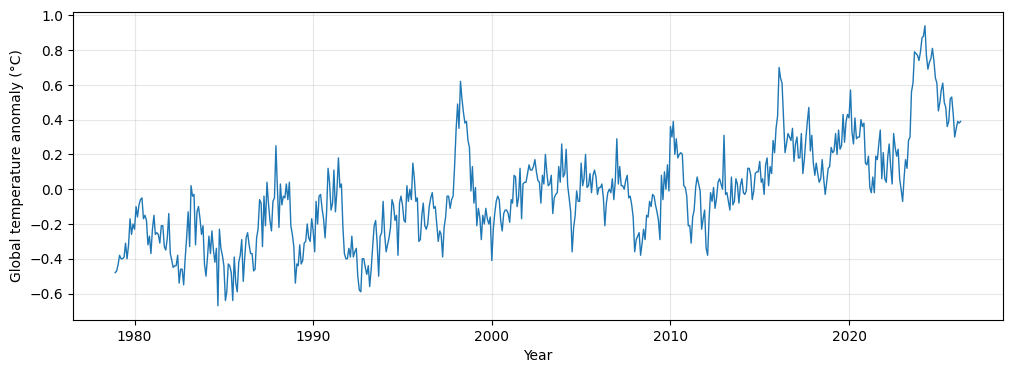

In [24]:
uah = uah.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 4))


ax.plot(uah["Date"], uah["Globe"], linewidth=1)

ax.set_ylabel("Global temperature anomaly (°C)")
ax.set_xlabel("Year")
ax.grid(True, alpha=0.3)

In [25]:
path_name = '../data/noaa.csv'

noaa = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=".",
    dtype={"Year": "int64", "Month": "int64"}
)

noaa["Date"] = pd.to_datetime(dict(year=noaa["Year"], month=noaa["Month"], day=1))

In [26]:
print(noaa)

     Year  Month  Anom       Date
0    1958      1  0.36 1958-01-01
1    1958      2  0.20 1958-02-01
2    1958      3  0.15 1958-03-01
3    1958      4  0.07 1958-04-01
4    1958      5  0.09 1958-05-01
..    ...    ...   ...        ...
799  2024      8  1.24 2024-08-01
800  2024      9  1.22 2024-09-01
801  2024     10  1.31 2024-10-01
802  2024     11  1.30 2024-11-01
803  2024     12  1.26 2024-12-01

[804 rows x 4 columns]


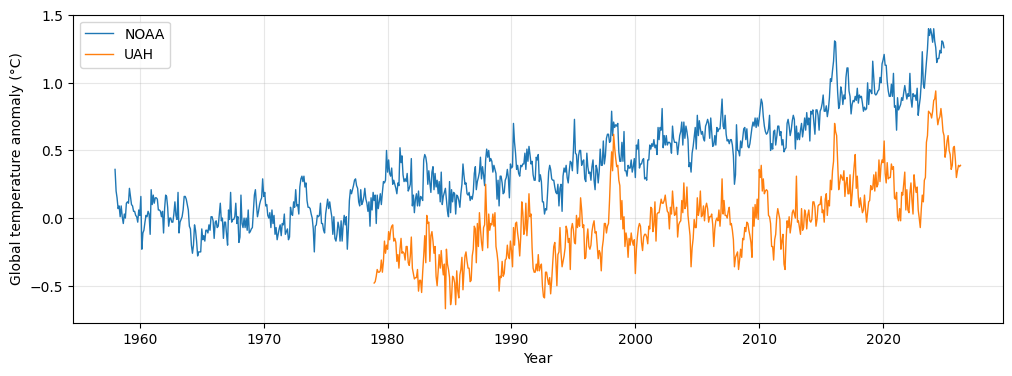

In [27]:
noaa = noaa.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 4))


ax.plot(noaa["Date"], noaa["Anom"], linewidth=1, label="NOAA")
ax.plot(uah["Date"], uah["Globe"], linewidth=1, label="UAH")

ax.set_ylabel("Global temperature anomaly (°C)")
ax.set_xlabel("Year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../img/temperature.pdf")

Slope      = 1.960
Intercept  = 2.043
r          = 0.801
R²         = 0.642
p-value    = 2.285e-11


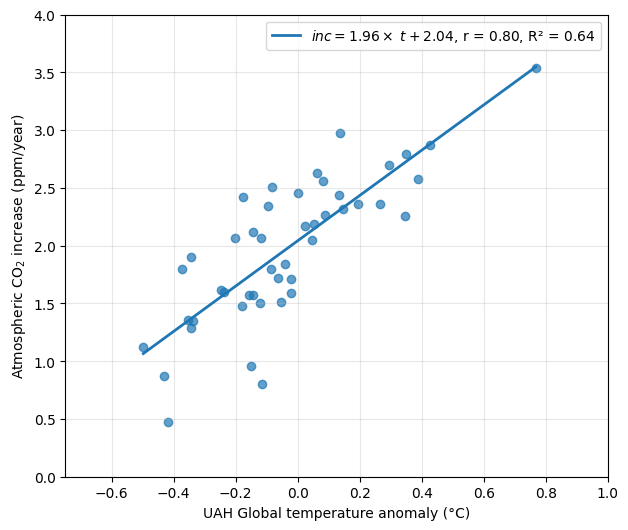

In [28]:
uah_year = (
    uah.loc[(uah["Year"] >= 1979) & (uah["Year"] <= 2024)]
       .groupby("Year")["Globe"]
       .mean()
       .reset_index()
       .rename(columns={"Year": "year", "Globe": "temp"})
       
)

x = uah_year["temp"]
y = atm.loc[(atm["year"] >= 1979) & (atm["year"] <= 2024)].reset_index(drop="True")["incr"]




res = linregress(x, y)

print(f"Slope      = {res.slope:.3f}")
print(f"Intercept  = {res.intercept:.3f}")
print(f"r          = {res.rvalue:.3f}")
print(f"R²         = {res.rvalue**2:.3f}")
print(f"p-value    = {res.pvalue:.3e}")

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter points
ax.scatter(x, y, alpha=0.7)

# Regression line
xx = np.linspace(x.min(), x.max(), 100)
yy = res.intercept + res.slope * xx

ax.plot(
    xx,
    yy,
    linewidth=2,
    label=f"$inc = {res.slope:.2f} \\times\\; t + {res.intercept:.2f}$, r = {res.rvalue:.2f}, R² = {res.rvalue**2:.2f}"
)
ax.set_xlim(-0.75,1)
ax.set_ylim(0,4)
ax.set_ylabel(r"Atmospheric CO$_2$ increase (ppm/year)")
ax.set_xlabel("UAH Global temperature anomaly (°C)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

Slope      = 1.751
Intercept  = 0.986
r          = 0.847
R²         = 0.717
p-value    = 3.483e-19


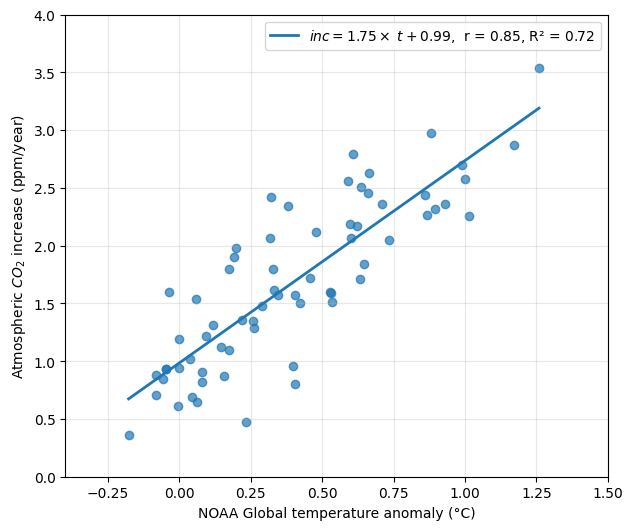

In [44]:
noaa_year = (
    noaa.loc[(noaa["Year"] >= 1959) & (noaa["Year"] <= 2024)]
    .groupby("Year")["Anom"]
    .mean()
    .reset_index()
    .rename(columns={"Year": "year", "Anom": "temp"})
)

x = noaa_year["temp"]
y = atm.loc[(atm["year"] >= 1959) & (atm["year"] <= 2024)].reset_index(drop="True")["incr"]



res = linregress(x, y)

print(f"Slope      = {res.slope:.3f}")
print(f"Intercept  = {res.intercept:.3f}")
print(f"r          = {res.rvalue:.3f}")
print(f"R²         = {res.rvalue**2:.3f}")
print(f"p-value    = {res.pvalue:.3e}")

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter points
ax.scatter(x, y, alpha=0.7)

# Regression line
xx = np.linspace(x.min(), x.max(), 100)
yy = res.intercept + res.slope * xx

ax.plot(
    xx,
    yy,
    linewidth=2,
    label=f"$inc = {res.slope:.2f} \\times\\; t + {res.intercept:.2f}$,  r = {res.rvalue:.2f}, R² = {res.rvalue**2:.2f}"
)
ax.set_xlim(-0.4, 1.5)
ax.set_ylim(0,4)
ax.set_ylabel(r"Atmospheric $CO_2$ increase (ppm/year)")
ax.set_xlabel("NOAA Global temperature anomaly (°C)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig("../carbon/img/temperature-ppm.pdf")
plt.show()

In [30]:
df = (
    atm
    .merge(noaa_year, on="year")
    .merge(fos, on="year")
)
X = df[["temp", "emi"]]
X = sm.add_constant(X)   # adds intercept

y = df["incr"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   incr   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     79.67
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           5.60e-18
Time:                        11:48:53   Log-Likelihood:                -29.514
No. Observations:                  66   AIC:                             65.03
Df Residuals:                      63   BIC:                             71.60
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0013      0.238      4.198      0.0

In [31]:
print(df[["incr", "temp", "emi"]].corr())


          incr      temp       emi
incr  1.000000  0.846543  0.794221
temp  0.846543  1.000000  0.939989
emi   0.794221  0.939989  1.000000


 root mean square error:  0.37844377180853217


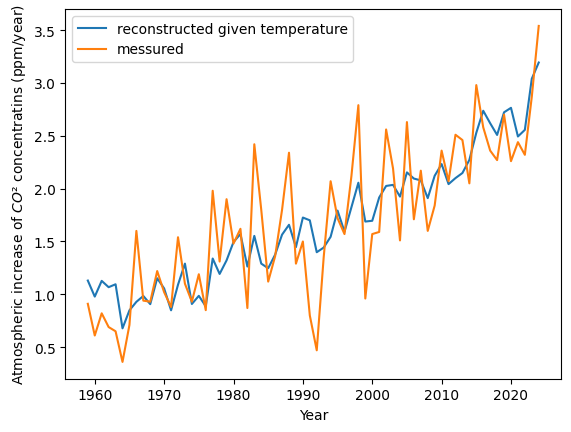

In [43]:
recon1 = noaa_year.copy()

# Predicted annual increase
recon1["incr"] = 1.75 * recon1["temp"] + 0.99

plt.plot(recon1["year"], recon1["incr"], label="reconstructed given temperature")
plt.plot(atm["year"], atm["incr"], label="messured")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric increase of $CO²$ concentratins (ppm/year)")
plt.legend()
plt.savefig("../carbon/img/recon_temp.pdf")

rmse = np.sqrt(np.mean((recon1["incr"] - atm["incr"])**2))

print(" root mean square error: ", rmse)

 root mean square error:  0.43223941832082124


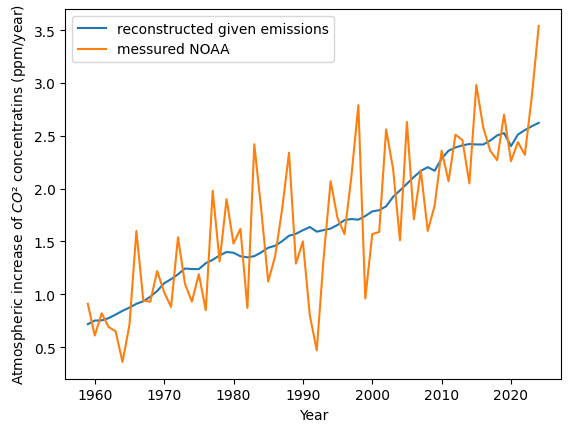

In [34]:
recon_em1 = fos.copy().reset_index()

# Predicted annual increase
recon_em1["incr"] = 0.5 * recon_em1["emi"] + 0.15

plt.plot(recon_em1["year"], recon_em1["incr"], label="reconstructed given emissions")
plt.plot(atm["year"], atm["incr"], label="messured NOAA")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric increase of $CO²$ concentratins (ppm/year)")
plt.legend()
plt.savefig("../carbon/img/recon_em1.pdf")

rmse = np.sqrt(np.mean((recon_em1["incr"] - atm["incr"])**2))

print(" root mean square error: ", rmse)

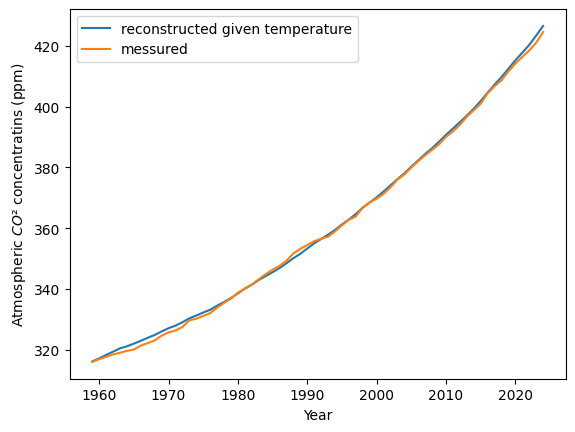

In [41]:
recon2 = noaa_year.copy()

# Predicted annual increase
recon2["incr"] = 1.75 * recon2["temp"] + 1.0

# Reconstructed concentration
recon2["co2"] = 315.0 + recon2["incr"].cumsum()

plt.plot(recon2["year"], recon2["co2"], label="reconstructed given temperature")
plt.plot(mauna.loc[(mauna["year"] >= 1959) & (mauna["year"] <= 2024)].groupby("year").mean()["average"], label="messured")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric $CO²$ concentratins (ppm)")
plt.legend()
plt.savefig("../carbon/img/recon2.pdf")

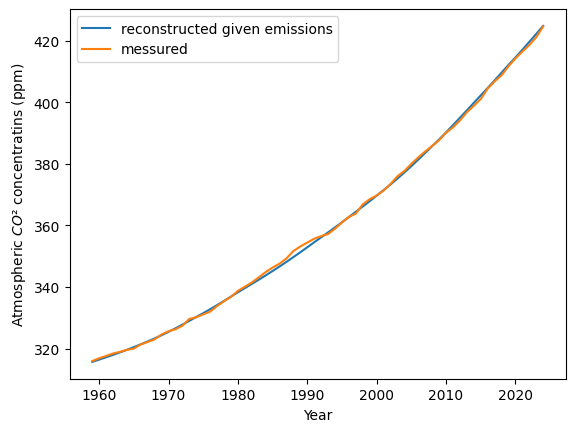

In [42]:
recon_em2 = fos.copy().reset_index()

# Predicted annual increase
recon_em2["incr"] = 0.5 * recon_em2["emi"] + 0.15

# Reconstructed concentration
recon_em2["co2"] = 315.0 + recon_em2["incr"].cumsum()

plt.plot(recon_em2["year"], recon_em2["co2"], label="reconstructed given emissions")
plt.plot(mauna.loc[(mauna["year"] >= 1959) & (mauna["year"] <= 2024)].groupby("year").mean()["average"], label="messured")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric $CO²$ concentratins (ppm)")
plt.legend()
plt.savefig("../carbon/img/recon_em2.pdf")

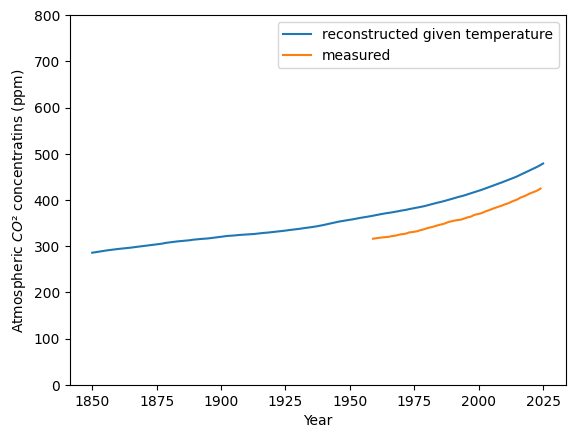

In [63]:
path_name = '../data/noaa-full.csv'

full = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=".",
    dtype={"Year": "int64", "Month":"int64", "Anom":"float64"})


noaa_full = (full.loc[(full["Year"] >= 1850) & (full["Year"] <= 2025)]
    .groupby("Year")["Anom"]
    .mean()
    .reset_index()
    .rename(columns={"Year": "year", "Anom":"anom"})
)




recon3 = noaa_full.copy()

# Predicted annual increase
recon3["incr"] = 1.75 * recon3["anom"] + 1

# Reconstructed concentration
recon3["co2"] = 285.0 + recon3["incr"].cumsum()

plt.plot(recon3["year"], recon3["co2"], label="reconstructed given temperature")
plt.plot(mauna.loc[(mauna["year"] >= 1959) & (mauna["year"] <= 2024)].groupby("year").mean()["average"], label="measured")
plt.ylim(0,800),
plt.xlabel("Year")
plt.ylabel(r"Atmospheric $CO²$ concentratins (ppm)")
plt.legend()
plt.savefig("../carbon/img/recon3.pdf")



[2024.           10.53454641    6.2672732   711.71272567]


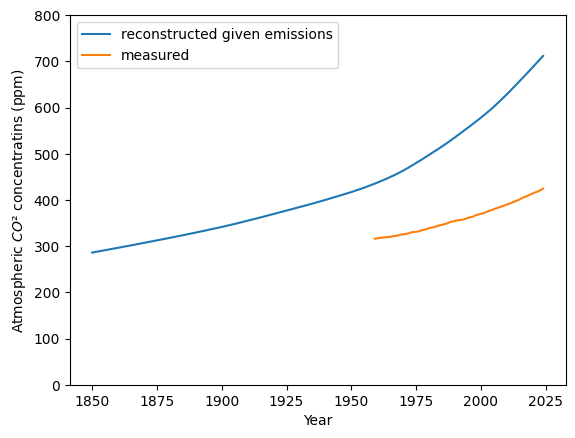

In [65]:
recon6 = fossil.loc[
    (fossil["Year"] >= 1850) &
    (fossil["Year"] <= 2024),
    ["Year", "Total"]].rename(columns={
    "Year": "year",
    "Total": "emi"
    }).copy()


# Predicted annual increase
recon6["incr"] = 0.5 * recon6["emi"] + 1

# Reconstructed concentration
recon6["co2"] = 285.0 + recon6["incr"].cumsum()

plt.plot(recon6["year"], recon6["co2"], label="reconstructed given emissions")
plt.plot(mauna.loc[(mauna["year"] >= 1959) & (mauna["year"] <= 2024)].groupby("year").mean()["average"], label="measured")
plt.ylim(0,800),
plt.xlabel("Year")
plt.ylabel(r"Atmospheric $CO²$ concentratins (ppm)")
plt.legend()
plt.savefig("../carbon/img/recon6.pdf")


print(recon6.values[-1])





In [66]:
uah_year = (
    uah.loc[(uah["Year"] >= 1959) & (uah["Year"] <= 2024)]
    .groupby("Year")["Globe"]
    .mean()
    .reset_index()
    .rename(columns={"Year": "year", "Globe": "temp"})
)

In [67]:

atm = mauna.loc[mauna["month"] == 12, ["year", "average"]].copy()

atm["incr"] = atm["average"].diff()
atm79 = atm.loc[(atm["year"] >= 1979) & (atm["year"] <= 2025),
              ["year", "incr"]].reset_index(drop="True")




 root mean square error:  1.454924114350482


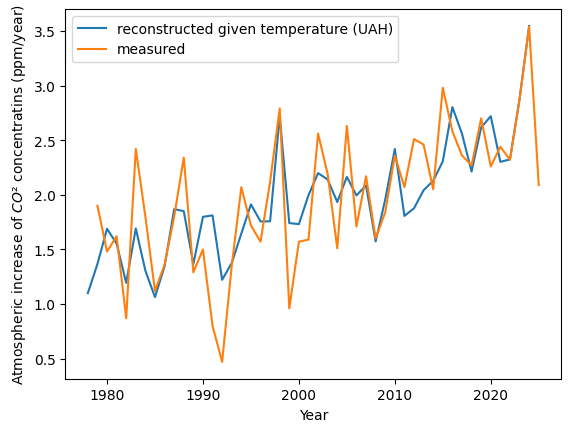

In [77]:
recon4 = uah_year.copy()

# Predicted annual increase
recon4["incr"] = 1.96 * recon4["temp"] + 2.04

plt.plot(recon4["year"],recon4["incr"], label="reconstructed given temperature (UAH)")
plt.plot(atm79["year"], atm79["incr"], label="measured")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric increase of $CO²$ concentratins (ppm/year)")
plt.legend()
plt.savefig("../carbon/img/recon4.pdf")

rmse = np.sqrt(np.mean((recon4["incr"] - atm["incr"])**2))

print(" root mean square error: ", rmse)

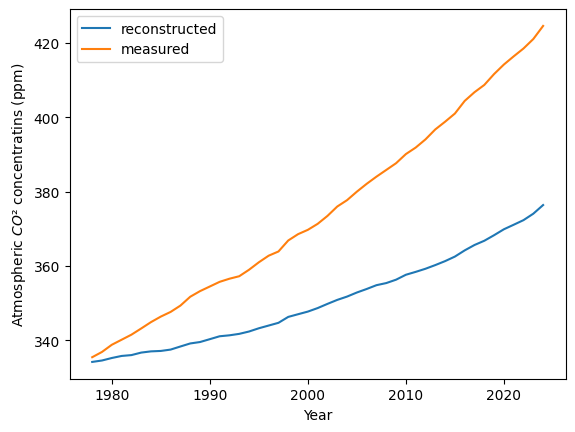

In [78]:
recon5 = uah_year.copy()

# Predicted annual increase
recon5["incr"] = res.slope * recon5["temp"] + res.intercept

# Reconstructed concentration
recon5["co2"] = 334.0 + recon5["incr"].cumsum()

plt.plot(recon5["year"], recon5["co2"], label="reconstructed")
plt.plot(mauna.loc[(mauna["year"] >= 1978) & (mauna["year"] <= 2024)].groupby("year").mean()["average"], label="measured")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric $CO²$ concentratins (ppm)")
plt.legend()
plt.savefig("../carbon/img/recon5.pdf")

In [79]:

incr = atm.loc[(atm["year"] >= 1959) & (atm["year"] <= 2024)].reset_index(drop="True")["incr"]


res = linregress(noaa_year["temp"], incr)

obs_r2 = res.rvalue ** 2

x = incr.shift(1).dropna()
y = incr[1:]



0.5911251553814223


<Figure size 1000x500 with 0 Axes>

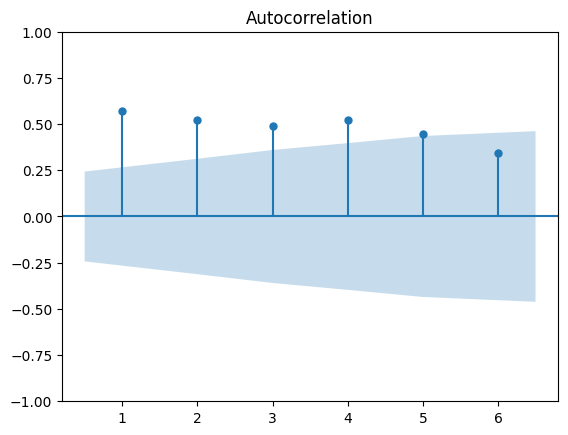

In [80]:
plt.figure(figsize=(10,5))
plot_acf(x, lags=[1,2,3,4,5,6], zero=False)

print(x.autocorr(lag=1))

plt.show()

In [81]:

phi, intercept, _, _, _ = linregress(x, y)

print("phi =", phi)
print("intercpet =", intercept)

phi = 0.6474629002874472
intercpet = 0.6218223341259772


In [82]:
resid = y - (intercept + phi*x)


sigma = resid.std()
mean = resid.mean()

print("sigma =", sigma)
print("mean =", mean)

sigma = 0.5625034960512991
mean = 1.1614640873001638e-16


0.5911251553814223


<Figure size 1000x500 with 0 Axes>

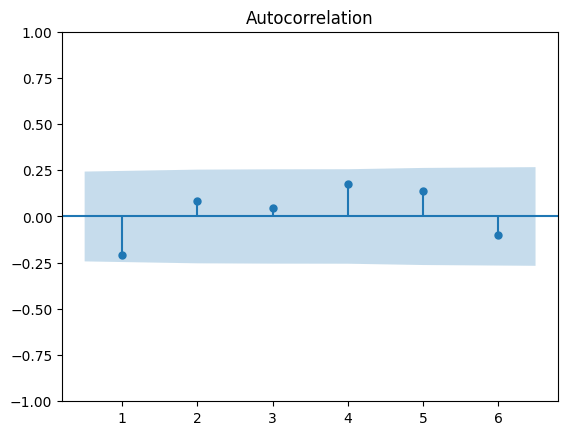

In [83]:
plt.figure(figsize=(10,5))
plot_acf(resid, lags=[1,2,3,4,5,6], zero=False)

print(x.autocorr(lag=1))

plt.show()

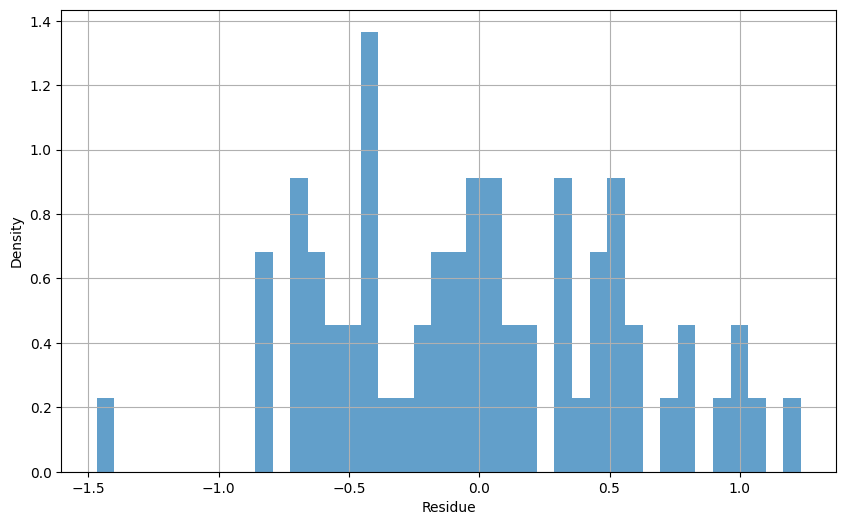

In [84]:
plt.figure(figsize=(10,6))

plt.hist(
    resid,
    bins=40,
    density=True,
    alpha=0.7
)



plt.xlabel("Residue")
plt.ylabel("Density")

plt.grid(True)

plt.show()

In [87]:
nsim = 100000


n = len(incr)

r2 = np.zeros(nsim)

for i in range(nsim):

    growth = np.zeros(n)

    growth[0] = incr.iloc[0]

    for t in range(1, n):

        growth[t] = (
            intercept
            + phi * growth[t-1]
            + np.random.normal(mean, sigma)
        )

    r2[i] = (np.corrcoef(incr, growth)[0,1] **2)

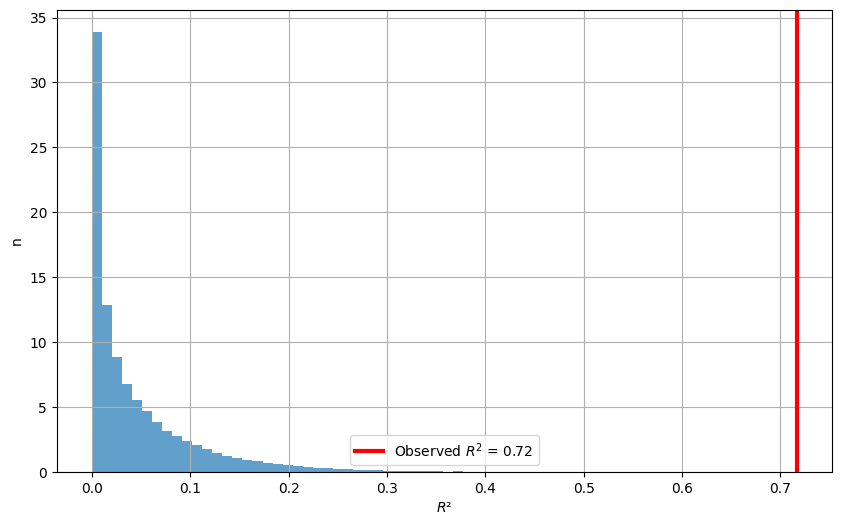

In [89]:
plt.figure(figsize=(10,6))

plt.hist(
    r2,
    bins=50,
    density=True,
    alpha=0.7
)

plt.axvline(
    obs_r2,
    color="red",
    linewidth=3,
    label=f"Observed $R^2$ = {obs_r2:.2f}"
)

plt.xlabel("$R²$")
plt.ylabel("n")
plt.legend()
plt.grid(True)
plt.savefig("../carbon/img/monte-r2.pdf")
plt.show()



In [90]:
p_value = np.mean(r2 >= obs_r2)

print("Observed R2:", obs_r2)
print("Monte Carlo p-value:", p_value)

print("Monte Carlo mean:", r2.mean())


srt = np.sort(r2)

q95 = srt[m.trunc(len(srt)*0.95)]
q99 = srt[m.trunc(len(srt)*0.99)]

print("Monte Carlo 95% :", q95)
print("Monte Carlo 99% :", q99)

Observed R2: 0.7166355934060226
Monte Carlo p-value: 0.0
Monte Carlo mean: 0.04495000092346427
Monte Carlo 95% : 0.16480669696670078
Monte Carlo 99% : 0.25365110813385366
